# Empirical loss dynamics

## Single run, greedy-sampled

/tmp/ipykernel_41889/1057300361.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Greens")


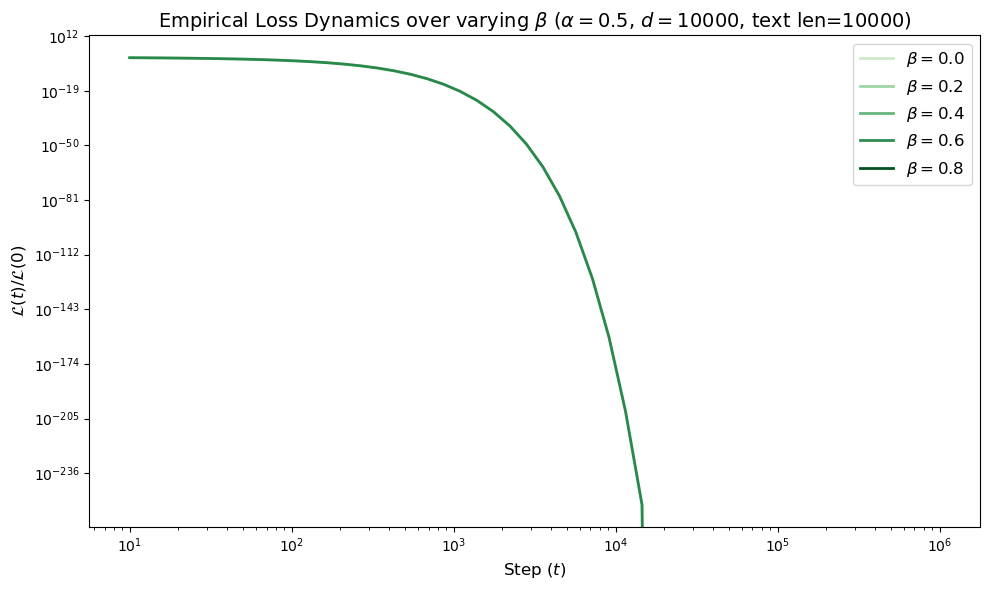

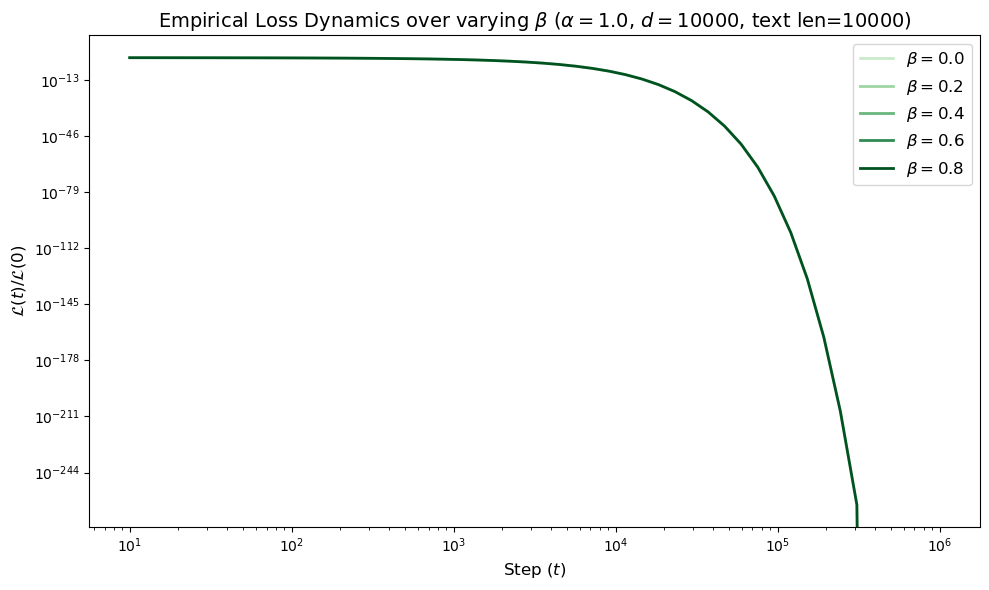

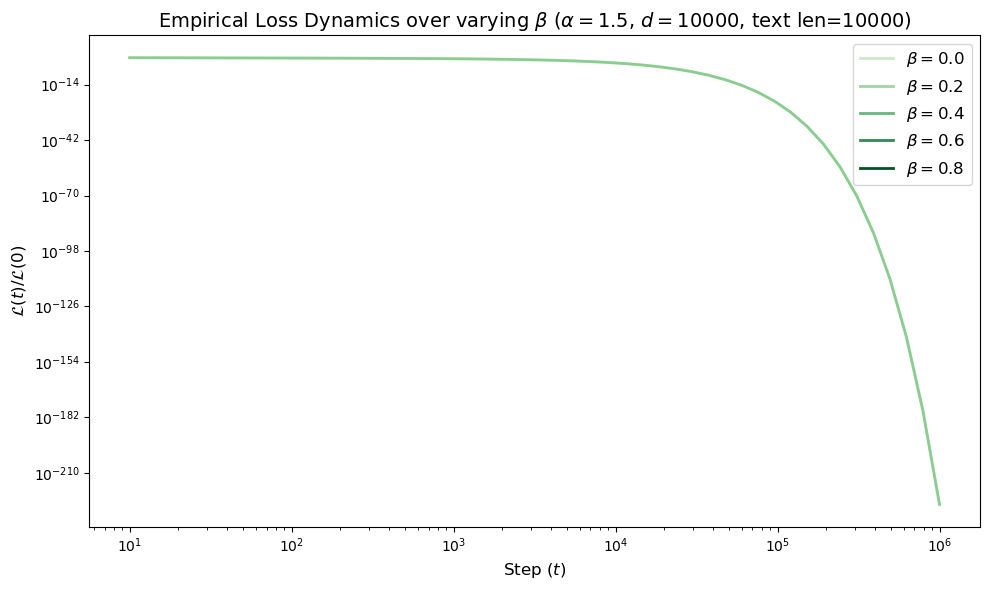

In [3]:
import matplotlib.pyplot as plt
import pickle
from EMPsims import EMPsingle
import matplotlib.cm as cm
import numpy as np

#----------Sim params-----------------
d = int(1e4)
seq_len = 10000
eta = 0.2
t_min = 10
t_max = 1e6
betas = [0.00, 0.2, 0.40, 0.6, 0.8]
alphas = [0.5, 1.0, 1.5]
num_betas = len(betas)

for alpha in alphas:
    #--------Sim function------------
    EMPsingle(d, alpha, betas, eta, seq_len, t_min, t_max)                  #put eta = 1/pi[0] for for bach case


    #--------Plotting---------------

    filepath = fr"/home/lucadriu/Desktop/uni/Tesi/Final/experiments/empirical/data/single/sim{alpha}_{d}_{seq_len}.pkl"

    with open(filepath, "rb") as f:
        data = pickle.load(f)

    t_steps = data["t_steps"]
    beta_keys = [k for k in data.keys() if k != "t_steps"]
    num_betas = len(beta_keys)

    cmap = cm.get_cmap("Greens")
    color_intensities = np.linspace(0.4, 0.95, num_betas)
    trasp = np.linspace(0.50, 1.0, num_betas)

    plt.figure(figsize=(10, 6))

    for i, key in enumerate(beta_keys):
        dynamics = data[key]

        beta_val = key.replace("beta_", "")

        plt.plot(t_steps,dynamics,linestyle="-",color=cmap(color_intensities[i]),
                alpha=trasp[i],linewidth=2.0,label=f"$\\beta = {beta_val}$")
        

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Step ($t$)", fontsize=12)
    plt.ylabel(r"$\mathcal{L}(t) / \mathcal{L}(0)$", fontsize=12)
    plt.title(rf"Empirical Loss Dynamics over varying $\beta$ ($\alpha={alpha}$, $d={d}$, text len={seq_len})",fontsize=14,)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

## Multiple run, greedy-sampled

In [1]:
import pickle
import numpy as np
from EMPsims import EMPmulti
import matplotlib.pyplot as plt
import matplotlib.cm as cm

#----------Sim params-----------------
d = 1000
seq_len = 100000
eta = 0.2
alpha = 1.5
t_min = 1e0
t_max = 1e7
betas = [0.00, 0.2, 0.40, 0.6, 0.8]
num_betas = len(betas)
n_runs = 10

filepath = EMPmulti(d, alpha, betas, eta, seq_len, t_min, t_max, n_runs)


with open(filepath, "rb") as f:
    data = pickle.load(f)

t_steps = data["t_steps"]
beta_mean_keys = [k for k in data.keys() if k.endswith("_mean")]
num_betas = len(beta_mean_keys)

cmap = cm.get_cmap("Greens")
color_intensities = np.linspace(0.4, 0.95, num_betas)
alphas = np.linspace(0.50, 1.0, num_betas)

plt.figure(figsize=(10, 6))

for i, mean_key in enumerate(beta_mean_keys):
    mean_dyn = data[mean_key]

    # Dynamically match standard deviation key
    std_key = mean_key.replace("_mean", "_std")
    std_dyn = data[std_key]

    # Extract clean beta string for display
    beta_val = mean_key.replace("beta_", "").replace("_mean", "")

    plt.plot(t_steps, mean_dyn, linestyle="-", color=cmap(color_intensities[i]),
             alpha=alphas[i], linewidth=2.0, label=f"$\\beta = {beta_val}$")
    
    plt.fill_between(t_steps, mean_dyn - std_dyn, mean_dyn + std_dyn,
                     color=cmap(color_intensities[i]), alpha=alphas[i] * 0.3)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Step ($t$)", fontsize=12)
plt.ylabel(r"$\mathcal{L}(t) / \mathcal{L}(0)$", fontsize=12)
plt.title(rf"Empirical Loss Dynamics ($\alpha={alpha}$, $d={d}$, len={seq_len}, nruns={n_runs})",fontsize=14,)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f"/home/lucadriu/Desktop/uni/Tesi/Final/experiments/empirical/plots/multi/multi{alpha}_{d}_{seq_len}_{n_runs}.jpg")
plt.show()


/home/lucadriu/Desktop/uni/Tesi/Final/experiments/empirical/MCsampling.py:54: RuntimeWarning: invalid value encountered in divide
  jump_probs = np.where(row_sums > 0, counts / row_sums, 0.0)


KeyboardInterrupt: 